<a href="https://colab.research.google.com/github/simasaadi/toronto-water-analytics/blob/main/notebooks/03_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 – Advanced Analysis of Toronto AOC1 Water-Quality Data

This notebook performs advanced analysis and visualization on the cleaned Toronto AOC1 water-quality dataset (`toronto_aoc1_clean.csv`).

While the previous notebooks focused on:

- **01_data_cleaning** – ingesting, cleaning, and standardizing the raw dataset  
- **02_exploration** – high-level exploratory data analysis (EDA) and basic visualizations  

this notebook goes deeper into **relationships, anomalies, temporal dynamics, and spatial patterns**.

### Analytical Objectives

1. Quantify relationships between key water-quality indicators and basic spatio-temporal features.
2. Detect and visualize statistical anomalies in measurement values.
3. Explore seasonal and long-term temporal patterns for high-priority parameters.
4. Identify spatial hotspots and clusters of monitoring locations with similar behaviour.
5. Produce publication-ready visualizations suitable for inclusion in dashboards or reports.

All analysis is performed using the cleaned dataset generated in `01_data_cleaning.ipynb`.


In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

print("Environment OK – libraries loaded.")


Environment OK – libraries loaded.


## 1. Load Cleaned Dataset

I start by loading the cleaned dataset produced in the data-cleaning step.  
The file is read directly from the Colab project directory used in the previous notebooks.

I also:

- parse the `activity_datetime` column as a proper datetime
- keep the engineered `year`, `month`, and `dayofweek` features created earlier
- confirm basic structure and size


In [3]:
# 0. Environment & Data Access Setup
#
# This cell:
# - Imports core libraries
# - Creates a /content/data/cleaned directory in Colab
# - Downloads the CLEANED dataset ZIP from GitHub
# - Unzips it
# - Automatically finds the cleaned CSV
# - Loads it into df and parses datetime fields

import os
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

# ------------------------------------------------------------------
# A) Directory structure (session-safe in Colab)
# ------------------------------------------------------------------
PROJECT_ROOT = "/content"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
CLEAN_DIR = os.path.join(DATA_DIR, "cleaned")

os.makedirs(CLEAN_DIR, exist_ok=True)

# ------------------------------------------------------------------
# B) Download cleaned ZIP from GitHub (RAW link)
# ------------------------------------------------------------------
ZIP_URL = (
    "https://raw.githubusercontent.com/simasaadi/toronto-water-analytics/"
    "main/data/cleaned/toronto_aoc1_clean.zip"
)
ZIP_PATH = os.path.join(CLEAN_DIR, "toronto_aoc1_clean.zip")

print("Downloading cleaned dataset from GitHub...")
!wget -q -O "$ZIP_PATH" "$ZIP_URL"
print("Download complete:", ZIP_PATH)

# ------------------------------------------------------------------
# C) Unzip into CLEAN_DIR
# ------------------------------------------------------------------
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(CLEAN_DIR)

print("\nFiles available in cleaned directory:")
!ls -lh "$CLEAN_DIR"

# ------------------------------------------------------------------
# D) Locate the cleaned CSV robustly
#    (handles names like 'toronto_aoc1_clean.csv' or '... (1).csv')
# ------------------------------------------------------------------
csv_candidates = [
    f for f in os.listdir(CLEAN_DIR)
    if f.lower().endswith(".csv")
]

if not csv_candidates:
    raise FileNotFoundError(
        f"No CSV files found in {CLEAN_DIR}. "
        "Check that the ZIP on GitHub contains a CSV."
    )

# Prefer a file that contains 'clean' in its name, otherwise take the first one
clean_csv = None
for f in csv_candidates:
    if "clean" in f.lower():
        clean_csv = f
        break
if clean_csv is None:
    clean_csv = csv_candidates[0]

clean_path = os.path.join(CLEAN_DIR, clean_csv)
print("\nUsing cleaned CSV:", clean_path)

# ------------------------------------------------------------------
# E) Load the dataset + basic parsing
# ------------------------------------------------------------------
df = pd.read_csv(clean_path, low_memory=False)

# Ensure datetime and calendar features are available
if "activity_datetime" in df.columns:
    df["activity_datetime"] = pd.to_datetime(
        df["activity_datetime"], errors="coerce"
    )
    # If year / month / dayofweek not present, create them
    if "year" not in df.columns:
        df["year"] = df["activity_datetime"].dt.year
    if "month" not in df.columns:
        df["month"] = df["activity_datetime"].dt.month
    if "dayofweek" not in df.columns:
        df["dayofweek"] = df["activity_datetime"].dt.day_name()

print("\nDataset loaded successfully.")
print("Rows, Columns:", df.shape)
df.head()


Download complete: /content/data/cleaned/toronto_aoc1_clean.zip

Files available in cleaned directory:
total 248M
-rw-r--r-- 1 root root 231M Nov 23 21:31 toronto_aoc1_clean.csv
-rw-r--r-- 1 root root  17M Nov 23 21:31 toronto_aoc1_clean.zip

Using cleaned CSV: /content/data/cleaned/toronto_aoc1_clean.csv

Dataset loaded successfully.
Rows, Columns: (770611, 22)


,id,doi,datasetname,monitoringlocationid,monitoringlocationname,monitoringlocationlatitude,monitoringlocationlongitude,monitoringlocationhorizontalcoordinatereferencesystem,monitoringlocationtype,activitytype,...,activitystarttime,samplecollectionequipmentname,characteristicname,resultvalue,resultunit,resultvaluetype,activity_datetime,year,month,dayofweek
0,119886859,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,"Temperature, water",15.0,deg C,Actual,2019-07-25,2019,7,Thursday
1,119886893,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,360.0,uS/cm,Actual,2021-07-15,2021,7,Thursday
2,119886896,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,NaN,pH,7.8,NaN,Actual,2019-07-18,2019,7,Thursday
3,119886916,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,369.0,uS/cm,Actual,2020-09-03,2020,9,Thursday
4,119886936,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,324.0,uS/cm,Actual,2020-09-17,2020,9,Thursday


### 1.1 Sanity Check – Types and Missingness

Before advanced analysis, I re-confirm:

- column data types
- missing-value counts
- number of unique locations and parameters

This mirrors the exploration notebook but is kept here so this analysis notebook can be run independently if needed.


In [4]:
print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values (count):")
print(df.isna().sum())

print("\nUnique Monitoring Locations:", df["monitoringlocationname"].nunique())
print("Unique Characteristics:", df["characteristicname"].nunique())



Column Types:
id                                                                int64
doi                                                              object
datasetname                                                      object
monitoringlocationid                                             object
monitoringlocationname                                           object
monitoringlocationlatitude                                      float64
monitoringlocationlongitude                                     float64
monitoringlocationhorizontalcoordinatereferencesystem            object
monitoringlocationtype                                           object
activitytype                                                     object
activitymedianame                                                object
activitystartdate                                                object
activitystarttime                                                object
samplecollectionequipmentname                    

## 2. Helper Configuration and Sampling Strategy

The dataset contains over **770k** records, so some visualizations use:

- a **subset of high-priority parameters** (core water-quality indicators), and
- **row sampling** for dense plots (e.g., pairplots) to keep runtime manageable.

The list below defines a set of core characteristics commonly used in water-quality assessments.


In [5]:
# Core characteristics used throughout the analysis (present in this dataset)
core_chars = [
    "Total Phosphorus, mixed forms",
    "Specific conductance",
    "Chloride",
    "Temperature, water",
    "Dissolved oxygen (DO)",
]

# Subset containing only these characteristics
df_core = df[df["characteristicname"].isin(core_chars)].copy()

print("Core subset rows:", len(df_core))
df_core["characteristicname"].value_counts()


Core subset rows: 156510


,count
characteristicname,
"Total Phosphorus, mixed forms",34537
Specific conductance,34337
Chloride,30382
"Temperature, water",28989
Dissolved oxygen (DO),28265


## 3. Correlation Structure Across Numeric Features

To understand broad relationships, I construct a correlation matrix using numeric features:

- `resultvalue` – measurement value  
- `monitoringlocationlatitude`, `monitoringlocationlongitude` – spatial coordinates  
- `year`, `month` – temporal context  

I compute:

- an overall correlation matrix, and  
- a correlation matrix restricted to the **core characteristics subset**, which is often more interpretable for water-quality analysis.


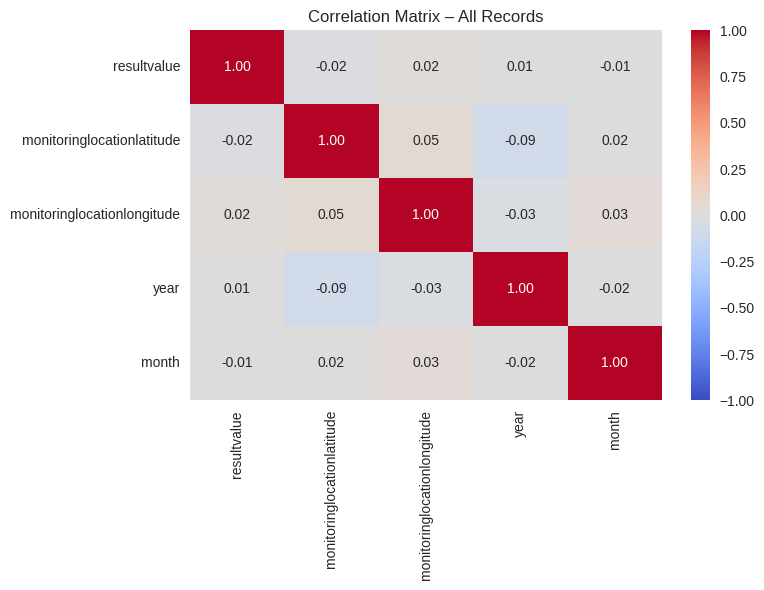

In [6]:
numeric_cols = [
    "resultvalue",
    "monitoringlocationlatitude",
    "monitoringlocationlongitude",
    "year",
    "month",
]

corr_all = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix – All Records")
plt.tight_layout()
plt.show()


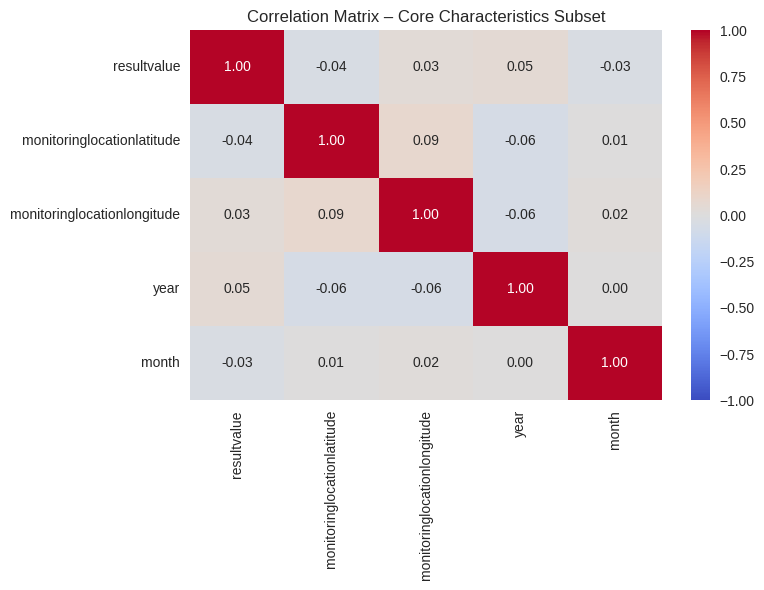

In [7]:
corr_core = df_core[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_core, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix – Core Characteristics Subset")
plt.tight_layout()
plt.show()


*Interpretation:*  

The correlation matrices provide a compact view of how measurement values co-vary with spatial and temporal coordinates, and whether there are systematic gradients (e.g., latitudinal patterns) or temporal trends (e.g., higher values in specific months or years).


## 4. Multi-Parameter Comparison by Characteristic

To compare the distribution of measurement values across parameters, I use:

- **log-scaled boxplots** (to handle extreme values)  
- **violin plots** for shape of the distribution

These plots are based on the `df_core` subset and therefore represent key indicators rather than all 100+ parameters.


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


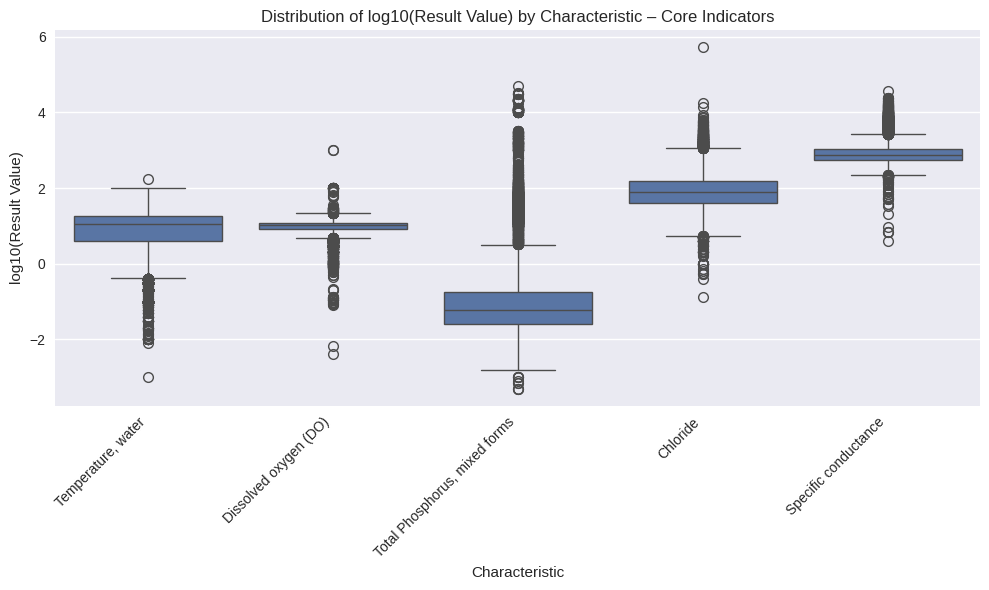

In [9]:
# Work on a copy and add a log-transformed column for visualization
df_core_plot = df_core.copy()
df_core_plot["resultvalue_log10"] = np.where(
    df_core_plot["resultvalue"] > 0,
    np.log10(df_core_plot["resultvalue"]),
    np.nan,
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_core_plot,
    x="characteristicname",
    y="resultvalue_log10"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("log10(Result Value)")
plt.xlabel("Characteristic")
plt.title("Distribution of log10(Result Value) by Characteristic – Core Indicators")
plt.tight_layout()
plt.show()


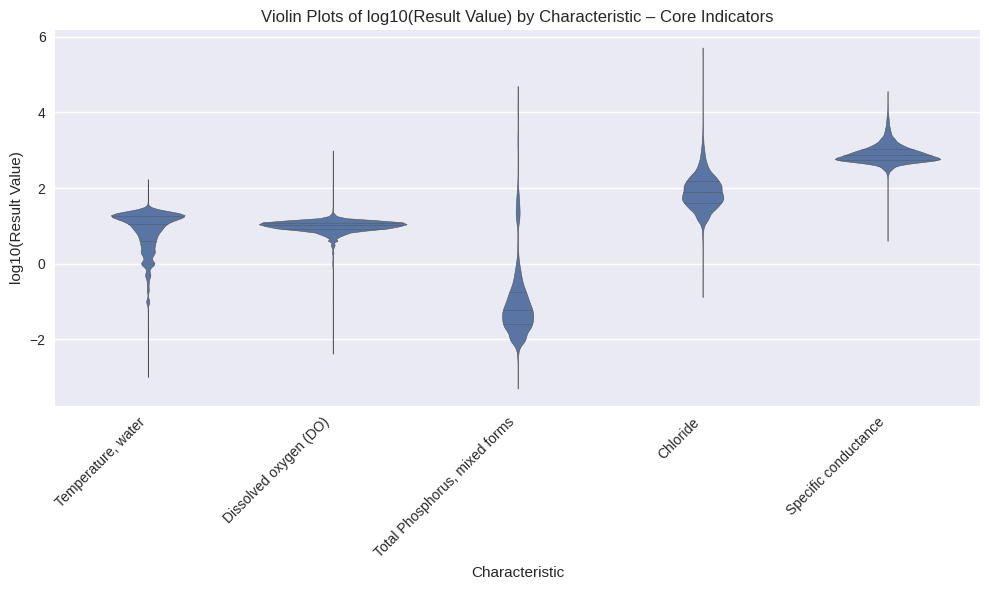

In [10]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_core_plot,
    x="characteristicname",
    y="resultvalue_log10",
    inner="quartile",
    cut=0
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("log10(Result Value)")
plt.xlabel("Characteristic")
plt.title("Violin Plots of log10(Result Value) by Characteristic – Core Indicators")
plt.tight_layout()
plt.show()


*Interpretation:*  

These plots highlight how the variability and central tendency of measurements differ across parameters.  
Parameters with very wide violins or long upper tails may require additional quality control or targeted analysis.


## 5. Pairwise Relationships (Sampled Pairplot)

To explore relationships between measurement value, time, and space, I generate a **pairplot** using a random sample of the core subset.

Variables included:

- `resultvalue_log10` – log-scaled measurement value  
- `year`  
- `month`  
- `monitoringlocationlatitude`, `monitoringlocationlongitude`  

I limit the sample to 5,000 rows to keep the plot interpretable and performant.


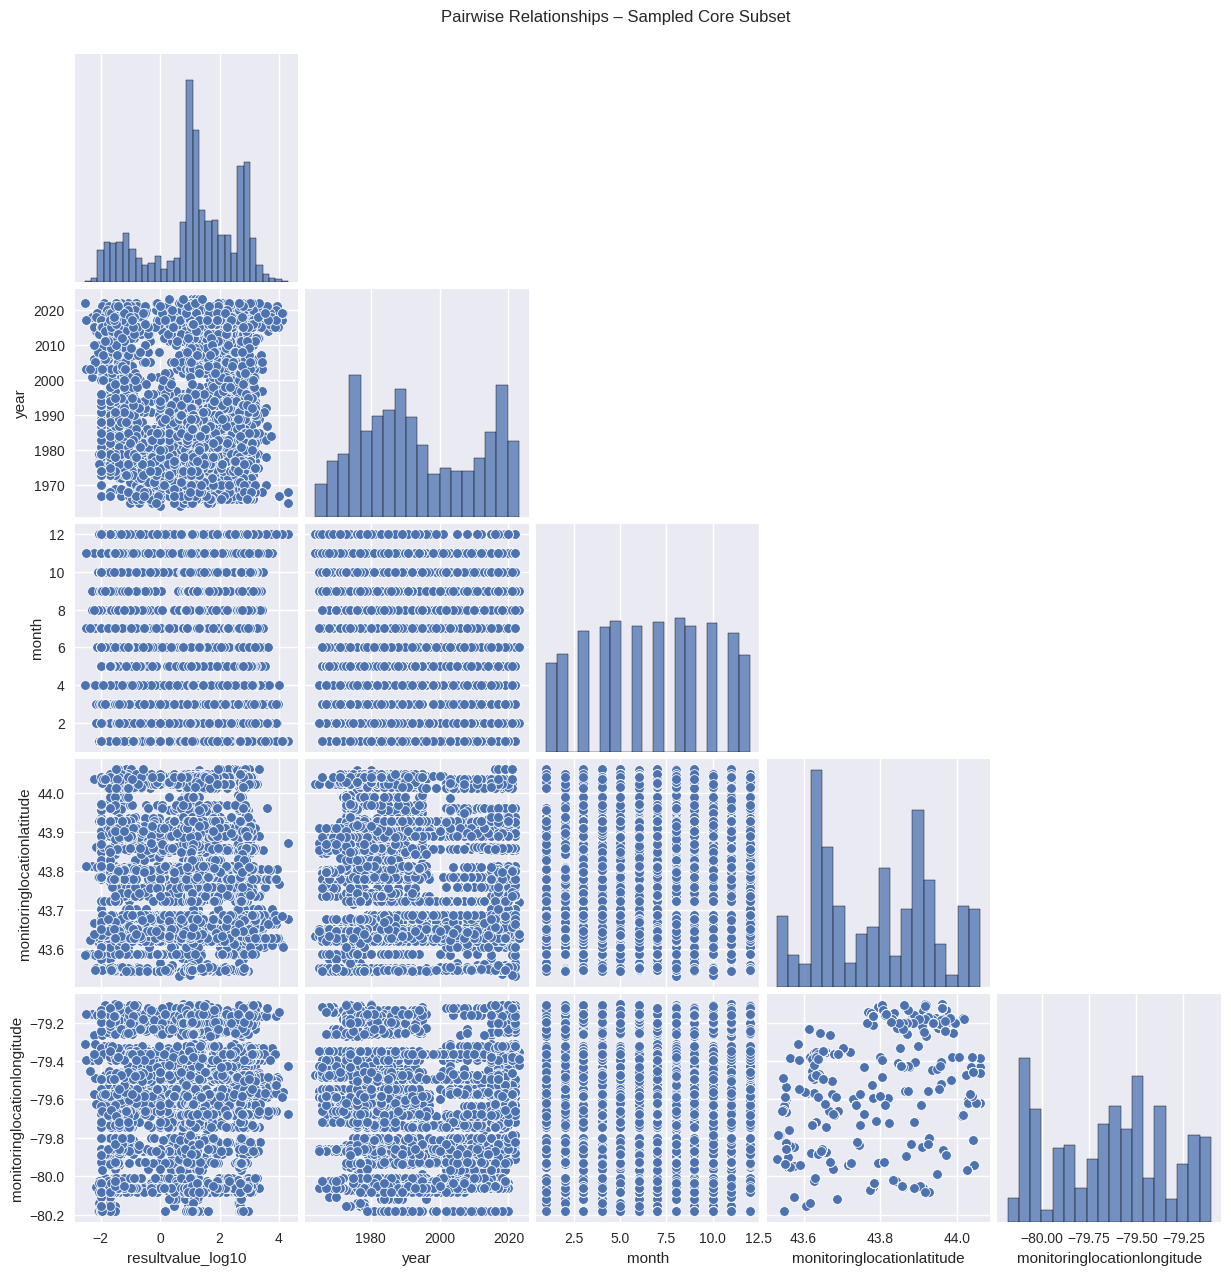

In [11]:
plot_vars = [
    "resultvalue_log10",
    "year",
    "month",
    "monitoringlocationlatitude",
    "monitoringlocationlongitude",
]

sample_size = min(5000, len(df_core_plot.dropna(subset=["resultvalue_log10"])))
df_sample = df_core_plot.dropna(subset=["resultvalue_log10"]).sample(
    sample_size, random_state=42
)

sns.pairplot(
    df_sample[plot_vars],
    corner=True,
    diag_kind="hist"
)
plt.suptitle("Pairwise Relationships – Sampled Core Subset", y=1.02)
plt.show()


## 6. Anomaly Detection Using Z-Scores

Next, I apply a simple **within-parameter z-score** approach:

1. For each `characteristicname`, compute the mean and standard deviation of `resultvalue`.
2. Convert each measurement to a **z-score** within its parameter group.
3. Flag observations with `|z| > 3` as **statistical anomalies**.

This is not a full outlier/QA procedure, but it provides a transparent first pass at flagging extreme values that may merit closer inspection.


In [12]:
df_core_z = df_core.copy()

# Compute z-scores within each characteristic
df_core_z["z_score"] = (
    df_core_z.groupby("characteristicname")["resultvalue"]
             .transform(lambda x: stats.zscore(x, nan_policy="omit"))
)

# Flag anomalies
z_threshold = 3.0
df_core_z["is_anomaly"] = df_core_z["z_score"].abs() > z_threshold

print("Total core rows:", len(df_core_z))
print("Anomalies detected (|z| > 3):", df_core_z["is_anomaly"].sum())

df_core_z[df_core_z["is_anomaly"]].head()


Total core rows: 156510
Anomalies detected (|z| > 3): 839


,id,doi,datasetname,monitoringlocationid,monitoringlocationname,monitoringlocationlatitude,monitoringlocationlongitude,monitoringlocationhorizontalcoordinatereferencesystem,monitoringlocationtype,activitytype,...,characteristicname,resultvalue,resultunit,resultvaluetype,activity_datetime,year,month,dayofweek,z_score,is_anomaly
15951,119888189,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,1393,Lake Ontario:Bathurst Quay,43.636450,-79.397000,UNKWN,Lake/Pond,Field Msr/Obs,...,"Temperature, water",173.0,deg C,Actual,2019-07-01 20:00:00,2019,7,Monday,19.806394,True
18819,200555245,10.25976/e90v-sv52,TRCA Regional Watershed Monitoring Program (RW...,97777,Rouge River 97777,43.852297,-79.330116,NAD83,Unspecified,Field Msr/Obs-Portable Data Logger,...,Specific conductance,5943.0,uS/cm,Actual,2015-01-19 00:00:00,2015,1,Monday,4.067782,True
19558,200588176,10.25976/e90v-sv52,TRCA Regional Watershed Monitoring Program (RW...,97777,Rouge River 97777,43.852297,-79.330116,NAD83,Unspecified,Field Msr/Obs-Portable Data Logger,...,Specific conductance,6542.0,uS/cm,Actual,2021-02-22 09:20:00,2021,2,Monday,4.564533,True
20036,200609357,10.25976/e90v-sv52,TRCA Regional Watershed Monitoring Program (RW...,97777,Rouge River 97777,43.852297,-79.330116,NAD83,Unspecified,Field Msr/Obs-Portable Data Logger,...,Specific conductance,5431.0,uS/cm,Actual,2018-01-22 08:30:00,2018,1,Monday,3.643181,True
20263,200620411,10.25976/e90v-sv52,TRCA Regional Watershed Monitoring Program (RW...,97777,Rouge River 97777,43.852297,-79.330116,NAD83,Unspecified,Field Msr/Obs-Portable Data Logger,...,Dissolved oxygen (DO),94.4,mg/L,Actual,2016-11-21 00:00:00,2016,11,Monday,9.071466,True


### 6.1 Visualizing Anomalies for a Single Parameter

For interpretability, I focus on one characteristic (e.g., **Total Phosphorus, mixed forms**) and plot:

- all measurements over time, and  
- anomalies highlighted in a different colour.

You can change `focus_char` to inspect other parameters.


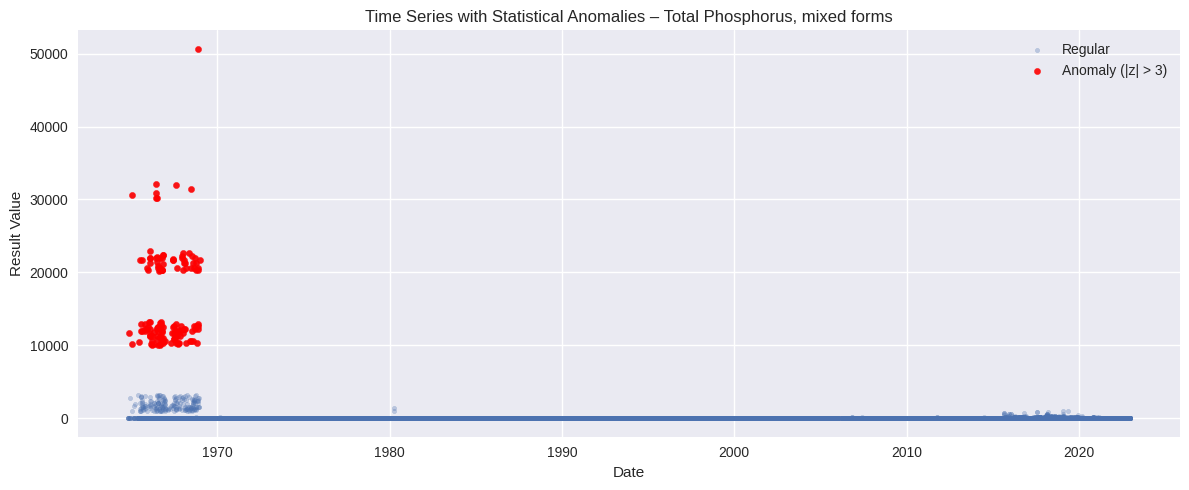

In [13]:
focus_char = "Total Phosphorus, mixed forms"

focus_df = df_core_z[df_core_z["characteristicname"] == focus_char].copy()
focus_df = focus_df.sort_values("activity_datetime")

plt.figure(figsize=(12, 5))
plt.scatter(
    focus_df["activity_datetime"],
    focus_df["resultvalue"],
    s=10,
    alpha=0.3,
    label="Regular"
)
plt.scatter(
    focus_df.loc[focus_df["is_anomaly"], "activity_datetime"],
    focus_df.loc[focus_df["is_anomaly"], "resultvalue"],
    s=20,
    alpha=0.9,
    color="red",
    label="Anomaly (|z| > 3)"
)
plt.title(f"Time Series with Statistical Anomalies – {focus_char}")
plt.xlabel("Date")
plt.ylabel("Result Value")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Temporal Dynamics and Seasonal Decomposition

To analyze longer-term behaviour, I:

1. Focus on a single key parameter (same `focus_char` as above).
2. Compute a **monthly mean time series**.
3. Apply **seasonal decomposition** (additive model) to split the signal into:
   - trend
   - seasonal component
   - residual

This helps distinguish long-term changes from regular seasonal cycles.


In [14]:
focus_series = (
    focus_df.set_index("activity_datetime")["resultvalue"]
             .resample("ME")  # Month end, consistent with future pandas versions
             .mean()
             .dropna()
)

focus_series.head()


,resultvalue
activity_datetime,
1964-10-31,5.165000
1964-11-30,2909.045000
1964-12-31,926.083333
1965-01-31,10460.250000
1965-02-28,0.716667


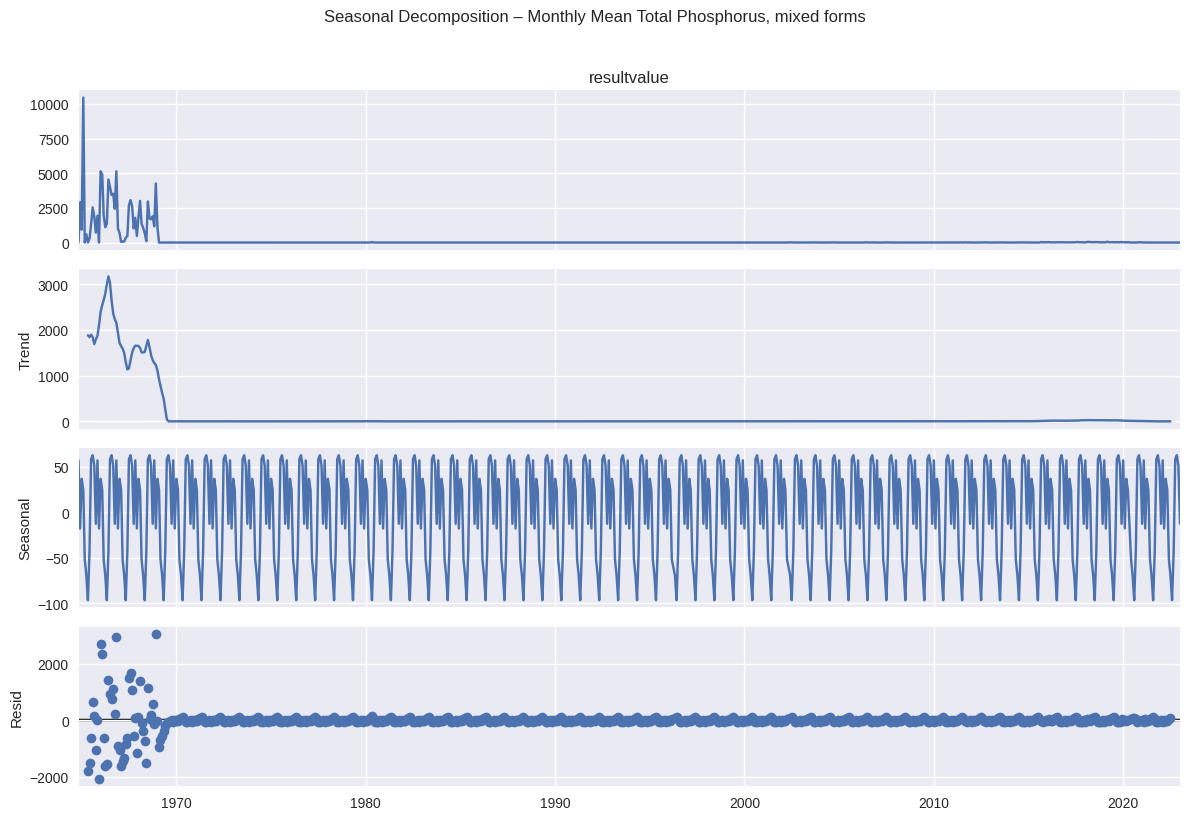

In [15]:
decomp = seasonal_decompose(focus_series, model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"Seasonal Decomposition – Monthly Mean {focus_char}", y=1.02)
plt.tight_layout()
plt.show()


## 8. Location–Month Heatmap (Hotspots)

To identify potential hotspots, I construct a **location–month heatmap**:

1. Select the top N monitoring locations by number of measurements.
2. Compute the **median `resultvalue`** for each `(location, month)` combination.
3. Pivot into a matrix: rows = locations, columns = months (1–12).
4. Plot as a heatmap.

Higher intensities represent higher typical measurement values in that month for a given site.


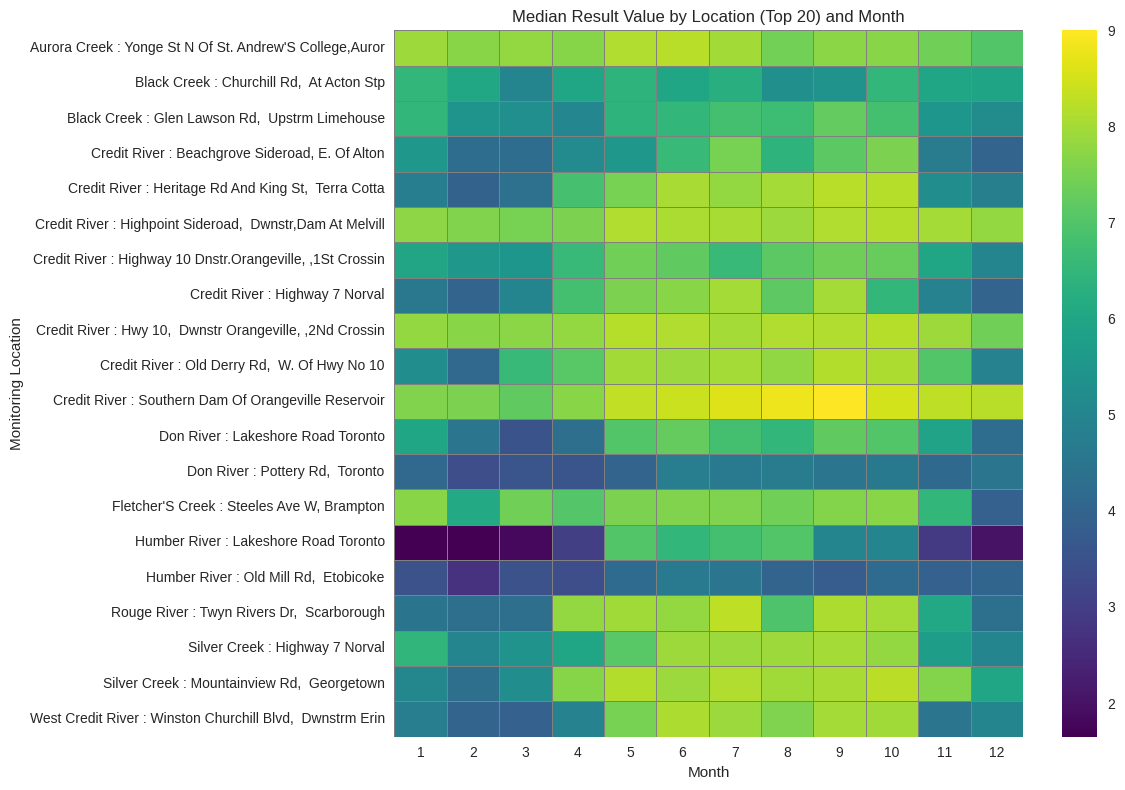

In [16]:
# Top N locations by measurement count
top_n = 20
top_locs = (
    df.groupby("monitoringlocationname")["resultvalue"]
      .count()
      .sort_values(ascending=False)
      .head(top_n)
      .index
)

heat_df = (
    df[df["monitoringlocationname"].isin(top_locs)]
    .groupby(["monitoringlocationname", "month"])["resultvalue"]
    .median()
    .reset_index()
)

heat_pivot = heat_df.pivot(
    index="monitoringlocationname",
    columns="month",
    values="resultvalue"
).sort_index()

plt.figure(figsize=(12, 8))
sns.heatmap(
    heat_pivot,
    cmap="viridis",
    linewidths=0.5,
    linecolor="grey"
)
plt.title(f"Median Result Value by Location (Top {top_n}) and Month")
plt.xlabel("Month")
plt.ylabel("Monitoring Location")
plt.tight_layout()
plt.show()


## 9. Spatial Patterns and Clustering of Monitoring Sites

To capture spatial structure, I:

1. Aggregate the dataset to the **location level**, computing:
   - mean `resultvalue`
   - count of measurements
2. Standardize numeric features.
3. Run **K-means clustering** (k = 4, configurable) to group locations with similar behaviour.
4. Visualize clusters on a simple latitude–longitude scatter plot.

This is not a full spatial model, but it provides a useful segmentation of sites.


In [17]:
loc_agg = (
    df.groupby(
        ["monitoringlocationid", "monitoringlocationname",
         "monitoringlocationlatitude", "monitoringlocationlongitude"]
    )["resultvalue"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

loc_agg.head()


,monitoringlocationid,monitoringlocationname,monitoringlocationlatitude,monitoringlocationlongitude,mean,median,std,count
0,08-179,Wilcox Lake,43.949049,-79.436034,123.665425,8.507056,356.480249,33
1,08-180,Eversley Lake,43.957772,-79.500823,9.174385,2.693537,13.859228,21
2,08-183,Unnamed lake,43.747219,-79.735133,97.929927,5.300000,293.260479,35
3,08-184,Heart Lake,43.740539,-79.795426,75.534779,8.778776,182.388287,32
4,08-188,Fairy Lake,43.621242,-80.048136,79.210063,9.399859,184.811486,35


In [18]:
# Prepare features for clustering
features = loc_agg[["mean", "median", "std", "count"]].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

k = 4  # you can experiment with different k
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
loc_agg["cluster"] = kmeans.fit_predict(X_scaled)

loc_agg["cluster"].value_counts()


,count
cluster,
0,618
3,20
1,9
2,1


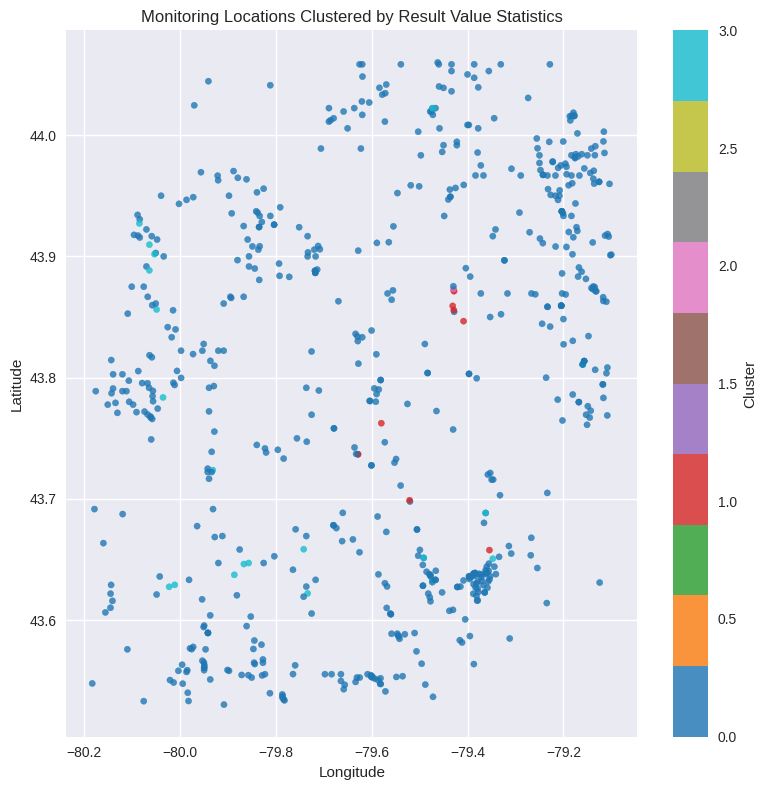

In [19]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    loc_agg["monitoringlocationlongitude"],
    loc_agg["monitoringlocationlatitude"],
    c=loc_agg["cluster"],
    s=20,
    alpha=0.8,
    cmap="tab10"
)
plt.colorbar(scatter, label="Cluster")
plt.title("Monitoring Locations Clustered by Result Value Statistics")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


*Interpretation:*  

Clusters can be interpreted as groups of sites with similar statistical profiles (e.g., consistently high values, high variability, or relatively clean conditions).  
These results can guide more detailed local investigations or targeted regulatory analysis.


## 10. Summary and Next Steps

This notebook extended the basic EDA by:

- quantifying correlations between measurement values and spatio-temporal features  
- comparing distributions of core water-quality parameters using boxplots and violin plots  
- detecting statistical anomalies via parameter-specific z-scores and visualizing them in time  
- decomposing a key parameter’s monthly time series into trend, seasonal, and residual components  
- constructing a location–month heatmap to reveal temporal hotspots  
- clustering monitoring locations based on summary statistics and mapping the resulting groups

These analyses provide a strong foundation for:

- **dashboard design** (e.g., Tableau Public in `04_export_for_tableau.ipynb`)  
- **policy-relevant narratives** about hotspots, temporal trends, and anomalous events  
- **further modelling** (e.g., regression, forecasting, or spatial interpolation) if needed.

The next step in the project is to export selected, analysis-ready tables (e.g., monthly summaries, location-level aggregates) for use in Tableau or other visualization tools.
